<a href="https://colab.research.google.com/github/Tejas7575/ML-Projects/blob/main/KMeans_cluster_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [ ]:
iris = load_iris()
X=iris.data
feature_names=iris.feature_names

df = pd.DataFrame(X,columns=feature_names)
print("First five rows of the dataset:")
print(df.head())

First five rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


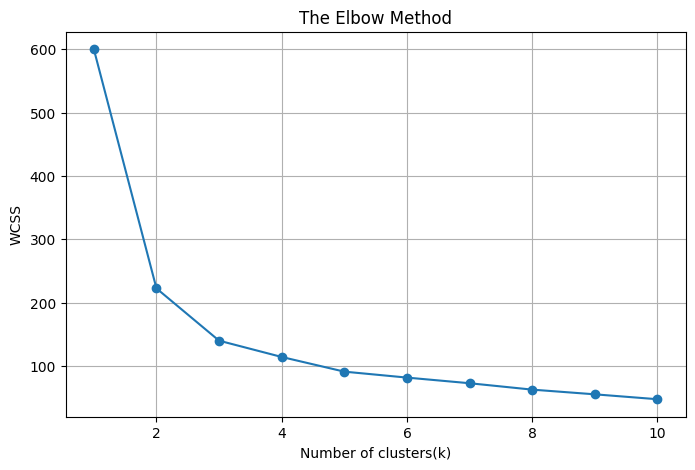

In [ ]:
from sklearn.cluster import KMeans
WCSS = []
for i in range (1,11):
  kmeans = KMeans( n_clusters=i , random_state=42 , n_init=10 )
  kmeans.fit(X_scaled)
  WCSS.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11),WCSS,marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters(k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)
clusters =kmeans.fit_predict(X_scaled)
df['cluster']=clusters

In [ ]:
# Silhowettr score
score = silhouette_score(X_scaled,clusters)
print("Silhouette Score:",score)

Silhouette Score: 0.45994823920518635


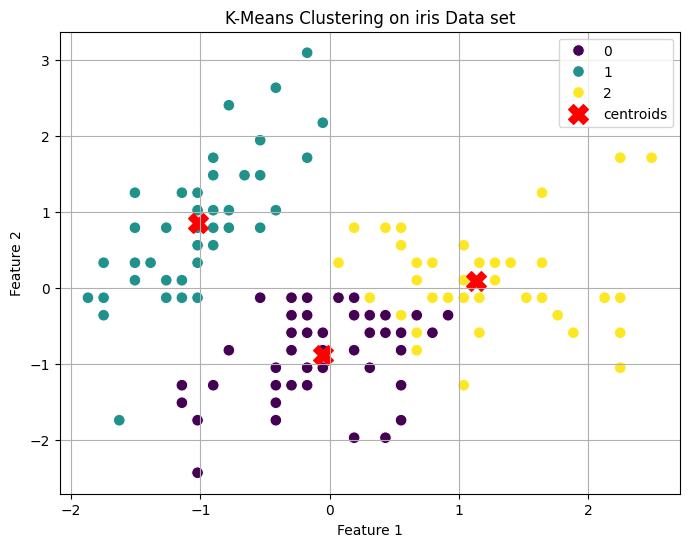

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_scaled[:,0],y=X_scaled[:,1],
                hue=clusters , palette = 'viridis',s=70)

centroids=kmeans.cluster_centers_
plt.scatter(centroids[:,0],centroids[:,1],s=200,c='red',marker='X',label='centroids')
plt.title('K-Means Clustering on iris Data set')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()